# Exercise session: Surface Energy Balance (SEB) Analysis at Hintereisferner Glacier (HEF)

## 1. Introduction and Objectives
This notebook analyzes high-resolution meteorological observations and Eddy Covariance (EddyPro) atmospheric flux measurements collected at the **Hintereisferner (HEF) Glacier** monitoring site.

### Key Objectives:
1. **Glacier Data Ingestion**: Import radiation, surface meteorological parameters, and Eddy Covariance outputs measured directly on the Hintereisferner Glacier (`data/HEF/`).
2. **Timestamp Alignment**: Parse high-frequency radiation and flux timeseries to standardized datetime indices over the target study period (August 18–24, 2023).
3. **Net Radiation Calculation**: Derive Net Radiation ($R_n$) from shortwave ($S_{\downarrow}, S_{\uparrow}$) and longwave ($L_{\downarrow}, L_{\uparrow}$) radiation components measured on the ice/snow surface:
   $$R_n = (S_{\text{Win}} - S_{\text{Wout}}) + (L_{\text{WinCor}} - L_{\text{WoutCor}})$$
4. **Surface Energy Balance (SEB) Closure**: Quantify consumed turbulent energy fluxes ($H + LE$) and evaluate the glacier surface energy residual ($R_n - (H + LE)$).

---

## 2. Environment Setup
Import standard software libraries required for data manipulation and visualization.

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

## 3. Ingestion of Glacier Surface Station Data
Load meteorological and radiation observations from the `T2_snowfox_lf.dat` station dataset deployed on Hintereisferner Glacier.

In [18]:
# File path to Hintereisferner Glacier station data
filename = 'data/HEF/T2_snowfox_lf.dat'

# Load data ignoring header metadata rows
df = pd.read_csv(filename, skiprows=[0, 2, 3])
df.columns

Index(['TIMESTAMP', 'RECORD', 'Batt_Min', 'PTemp_Avg', 'Tair_1_Avg',
       'Tair_2_Avg', 'Hum_1_Avg', 'Hum_2_Avg', 'SWin_Avg', 'SWout_Avg',
       'LWin_Avg', 'LWout_Avg', 'CNR4TC_Avg', 'LWinCor_Avg', 'LWoutCor_Avg',
       'Wspeed', 'Wdir', 'Wspeed_Max', 'DT_raw', 'Q', 'TCDT', 'Snow_Depth',
       'Press_Avg'],
      dtype='object')

## 4. Parameter Selection & Time Index Filtering
Select target micrometeorological variables (air temperature, radiation, snow depth, pressure) and filter data for the active campaign window on HEF Glacier.

In [19]:
# Define target meteorological and radiative variables
vars_sel = [
    'TIMESTAMP', 'Tair_2_Avg', 'Hum_2_Avg', 'SWin_Avg', 'SWout_Avg',
    'LWinCor_Avg', 'LWoutCor_Avg', 'Wspeed', 'Wdir', 'Snow_Depth', 'Press_Avg'
]

# Subset dataset and parse datetime index
df_sel = df[vars_sel].copy()
df_sel["datetime"] = pd.to_datetime(df_sel["TIMESTAMP"])
df_sel = df_sel.set_index("datetime")

# Restrict analysis to target campaign window on HEF Glacier
df_sel = df_sel.loc['2023-08-18':'2023-08-24']
df_sel

,TIMESTAMP,Tair_2_Avg,Hum_2_Avg,SWin_Avg,SWout_Avg,LWinCor_Avg,LWoutCor_Avg,Wspeed,Wdir,Snow_Depth,Press_Avg
datetime,,,,,,,,,,,
2023-08-18 00:00:00,2023-08-18 00:00:00,8.25,63.39,-2.560577,5.368653,292.2883,325.0677,3.276,36.06,2.342,772.0770
2023-08-18 00:10:00,2023-08-18 00:10:00,8.38,62.49,-2.111928,4.789963,294.8687,325.1245,3.088,348.90,2.340,771.9927
2023-08-18 00:20:00,2023-08-18 00:20:00,8.46,61.83,-1.915595,4.607724,294.9255,325.3869,3.820,353.10,2.333,771.9089
2023-08-18 00:30:00,2023-08-18 00:30:00,8.45,61.94,-1.376733,3.770021,294.7963,325.3098,2.460,19.03,2.341,771.8354
2023-08-18 00:40:00,2023-08-18 00:40:00,8.36,62.12,-1.277114,3.929176,294.4223,324.9171,2.904,313.80,2.341,771.7762
...,...,...,...,...,...,...,...,...,...,...,...
2023-08-24 23:10:00,2023-08-24 23:10:00,10.09,70.08,0.517271,1.503484,302.2755,327.6053,1.976,190.70,2.351,771.4700
2023-08-24 23:20:00,2023-08-24 23:20:00,10.67,58.26,0.241509,1.788020,300.0252,327.3498,3.608,191.30,2.347,771.3122
2023-08-24 23:30:00,2023-08-24 23:30:00,11.20,53.82,-0.533818,1.144777,299.9792,328.4235,3.530,186.60,2.349,771.1617


## 5. Ingestion of HEF Glacier Eddy Covariance Output
Load raw EddyPro atmospheric flux calculation outputs corresponding to the CSAT sonic anemometer deployed at Hintereisferner Glacier.

In [20]:
# File path to EddyPro full output file for HEF Glacier
file_path = "data/HEF/eddypro_csat_full_output_2026-10-08T083750_exp.csv"

# Load CSV ignoring top metadata header rows and treating -9999 as missing values
df_eddy = pd.read_csv(file_path, sep=",", skiprows=[0, 2], na_values=-9999)

# Inspect column names
print(df_eddy.columns)

Index(['filename', 'date', 'time', 'DOY', 'daytime', 'file_records',
       'used_records', 'Tau', 'qc_Tau', 'H',
       ...
       'ts_var', 'co2_var', 'h2o_var', 'w/ts_cov', 'w/co2_cov', 'w/h2o_cov',
       'u_mean', 'v_mean', 'w_mean', 'ts_mean'],
      dtype='object', length=114)


## 6. Resampling Turbulent Fluxes to Hourly Resolution
Parse datetime fields for turbulent fluxes ($H$, $LE$) and aggregate parameters into regular $1\text{-hour}$ averages.

In [21]:
# Select target micrometeorological and turbulent flux variables
df_sel_eddy = df_eddy[["date", "time", "H", "LE", "air_temperature", "air_pressure", "RH", "wind_speed", "wind_dir"]].copy()

# Construct datetime index and resample to 1-hour averages
df_sel_eddy["datetime"] = pd.to_datetime(df_sel_eddy["date"] + " " + df_sel_eddy["time"])
df_sel_eddy = df_sel_eddy.set_index("datetime").drop(columns=["date", "time"]).resample("1h").mean()
df_sel_eddy

,H,LE,air_temperature,air_pressure,RH,wind_speed,wind_dir
datetime,,,,,,,
2023-08-18 00:00:00,-74.23790,-0.560993,280.9550,73687.90,59.60950,1.745100,85.61770
2023-08-18 01:00:00,-58.88075,5.804810,280.5295,73679.85,72.67340,1.595065,111.35575
2023-08-18 02:00:00,-83.92820,-9.094605,280.5100,73673.50,86.43345,1.335736,179.32750
2023-08-18 03:00:00,-64.31990,-9.001115,280.6055,73668.25,86.46215,0.992816,150.40445
2023-08-18 04:00:00,-58.30555,-11.789285,280.6745,73671.70,87.71760,1.159784,58.81815
...,...,...,...,...,...,...,...
2023-08-25 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-25 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-25 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Dataset Integration & SEB Component Derivation
Merge surface station radiation observations with Eddy Covariance turbulent heat fluxes and compute Net Radiation ($R_n$), consumed energy ($H + LE$), and surface imbalance.

In [22]:
# Select radiation components from station data and turbulent fluxes from EddyPro
cols_tower = ['SWin_Avg', 'SWout_Avg', 'LWinCor_Avg', 'LWoutCor_Avg']
cols_eddy = ["H", "LE"]

# Merge datasets on common datetime index
df_merged = pd.merge(df_sel[cols_tower], df_sel_eddy[cols_eddy], on="datetime", how="inner").loc['2023-08-18':'2023-08-24']
df_merged

,SWin_Avg,SWout_Avg,LWinCor_Avg,LWoutCor_Avg,H,LE
datetime,,,,,,
2023-08-18 00:00:00,-2.560577,5.368653,292.2883,325.0677,-74.23790,-0.560993
2023-08-18 01:00:00,0.185919,3.551950,302.6955,325.2170,-58.88075,5.804810
2023-08-18 02:00:00,-0.302615,1.084664,307.3164,325.8494,-83.92820,-9.094605
2023-08-18 03:00:00,-0.468870,1.171565,305.7386,325.6292,-64.31990,-9.001115
2023-08-18 04:00:00,0.045711,0.735096,320.9299,325.9255,-58.30555,-11.789285
...,...,...,...,...,...,...
2023-08-24 19:00:00,-1.592874,-0.312306,303.5416,331.7068,-74.75720,-27.439200
2023-08-24 20:00:00,-1.213692,-0.217152,316.5309,331.6024,NaN,NaN
2023-08-24 21:00:00,-1.344232,-0.017114,354.0774,332.7958,NaN,NaN


In [23]:
# Compute Net Radiation (Rn) and Surface Energy Balance (SEB) terms
df_merged["Rn"] = (df_merged["SWin_Avg"] - df_merged["SWout_Avg"]) + (df_merged["LWinCor_Avg"] - df_merged["LWoutCor_Avg"])
df_merged["SEB_Consumed"] = df_merged["H"] + df_merged["LE"]
df_merged["SEB_Residual"] = df_merged["Rn"] - df_merged["SEB_Consumed"]
df_merged

,SWin_Avg,SWout_Avg,LWinCor_Avg,LWoutCor_Avg,H,LE,Rn,SEB_Consumed,SEB_Residual
datetime,,,,,,,,,
2023-08-18 00:00:00,-2.560577,5.368653,292.2883,325.0677,-74.23790,-0.560993,-40.708630,-74.798893,34.090263
2023-08-18 01:00:00,0.185919,3.551950,302.6955,325.2170,-58.88075,5.804810,-25.887531,-53.075940,27.188409
2023-08-18 02:00:00,-0.302615,1.084664,307.3164,325.8494,-83.92820,-9.094605,-19.920279,-93.022805,73.102526
2023-08-18 03:00:00,-0.468870,1.171565,305.7386,325.6292,-64.31990,-9.001115,-21.531035,-73.321015,51.789980
2023-08-18 04:00:00,0.045711,0.735096,320.9299,325.9255,-58.30555,-11.789285,-5.684986,-70.094835,64.409849
...,...,...,...,...,...,...,...,...,...
2023-08-24 19:00:00,-1.592874,-0.312306,303.5416,331.7068,-74.75720,-27.439200,-29.445768,-102.196400,72.750632
2023-08-24 20:00:00,-1.213692,-0.217152,316.5309,331.6024,NaN,NaN,-16.068040,NaN,NaN
2023-08-24 21:00:00,-1.344232,-0.017114,354.0774,332.7958,NaN,NaN,19.954482,NaN,NaN


## 8. Surface Energy Balance Closure Visualization
Display time series of shortwave/longwave radiation components, turbulent heat fluxes ($H$, $LE$), and overall surface energy balance closure on Hintereisferner Glacier.

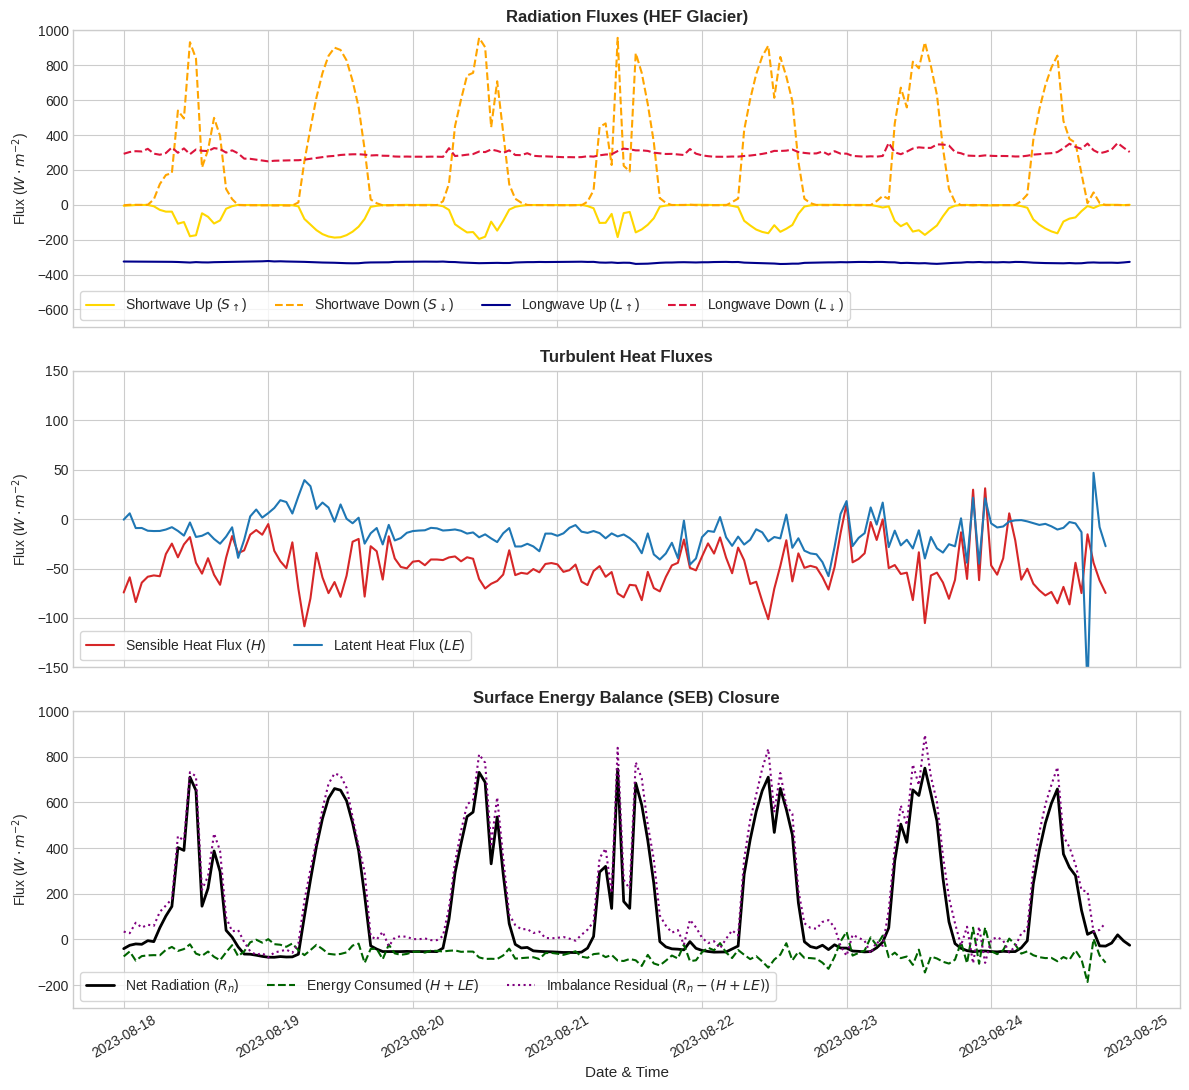

In [24]:
# Figure setup for HEF Glacier SEB analysis
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# --- Subplot 1: Radiation Fluxes ---
ax1.plot(
    df_merged.index,
    -df_merged["SWout_Avg"],
    label="Shortwave Up ($S_{\\uparrow}$)",
    color="gold",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["SWin_Avg"],
    label="Shortwave Down ($S_{\\downarrow}$)",
    color="orange",
    linestyle="--",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    -df_merged["LWoutCor_Avg"],
    label="Longwave Up ($L_{\\uparrow}$)",
    color="darkblue",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["LWinCor_Avg"],
    label="Longwave Down ($L_{\downarrow}$)",
    color="crimson",
    linestyle="--",
    linewidth=1.5,
)
ax1.set_ylabel("Flux ($W \\cdot m^{-2}$)", fontsize=10)
ax1.set_title("Radiation Fluxes (HEF Glacier)", fontsize=12, fontweight="bold")
ax1.set_ylim(-700, 1000)
ax1.legend(loc="lower left", frameon=True, ncol=4)

# --- Subplot 2: Turbulent Heat Fluxes ---
ax2.plot(
    df_merged.index,
    df_merged["H"],
    label="Sensible Heat Flux ($H$)",
    color="tab:red",
    linewidth=1.5,
)
ax2.plot(
    df_merged.index,
    df_merged["LE"],
    label="Latent Heat Flux ($LE$)",
    color="tab:blue",
    linewidth=1.5,
)
ax2.set_ylabel("Flux ($W \\cdot m^{-2}$)", fontsize=10)
ax2.set_ylim(-150, 150)
ax2.set_title("Turbulent Heat Fluxes", fontsize=12, fontweight="bold")
ax2.legend(loc="lower left", frameon=True, ncol=3)

# --- Subplot 3: Surface Energy Balance (SEB) ---
ax3.plot(
    df_merged.index,
    df_merged["Rn"],
    label="Net Radiation ($R_n$)",
    color="black",
    linewidth=2,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Consumed"],
    label="Energy Consumed ($H + LE$)",
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Residual"],
    label="Imbalance Residual ($R_n - (H+LE)$)",
    color="purple",
    linestyle=":",
    linewidth=1.5,
)
ax3.set_ylabel("Flux ($W \\cdot m^{-2}$)", fontsize=10)
ax3.set_ylim(-300, 1000)
ax3.set_xlabel("Date & Time", fontsize=11)
ax3.set_title("Surface Energy Balance (SEB) Closure", fontsize=12, fontweight="bold")
ax3.legend(loc="lower left", frameon=True, ncol=3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()